## Case Study - Mt Isa City

This case study sets to understand signal processing, the process and allow for a future framework to be built. <br>
Mt Isa City is a mineral rich mining town [1], and was selected due to the expected flucations in background noise.

_Install Packages and Modules_

In [30]:
import matplotlib.pyplot as plt
import numpy as np
from obspy import UTCDateTime
from obspy.clients.fdsn import Client

_Pull Data_

In [31]:
cl = Client("EARTHSCOPE")

st = cl.get_waveforms(network="AU", station="QIS",
                      location="00", channel="BHZ",
                      starttime=UTCDateTime("2024-08-09T06:35:09"), endtime=UTCDateTime("2024-08-09T18:35:09"))
tr = st[0]

The network, Australian National Seismograph Network (AU) [2], and the Mount Isa station (QIS).

In [32]:
print(tr.stats)

               network: AU
               station: QIS
              location: 00
               channel: BHZ
             starttime: 2024-08-09T06:35:09.000000Z
               endtime: 2024-08-09T18:35:09.000000Z
         sampling_rate: 40.0
                 delta: 0.025
                  npts: 1728001
                 calib: 1.0
_fdsnws_dataselect_url: https://service.earthscope.org/fdsnws/dataselect/1/query
               _format: MSEED
                 mseed: AttribDict({'dataquality': 'M', 'number_of_records': 4199, 'encoding': 'STEIM1', 'byteorder': '>', 'record_length': 512, 'filesize': 1048576})
            processing: ['ObsPy 1.5.0: trim(endtime=UTCDateTime(2024, 8, 9, 18, 35, 9)::fill_value=None::nearest_sample=True::pad=False::starttime=UTCDateTime(2024, 8, 9, 6, 35, 9))']


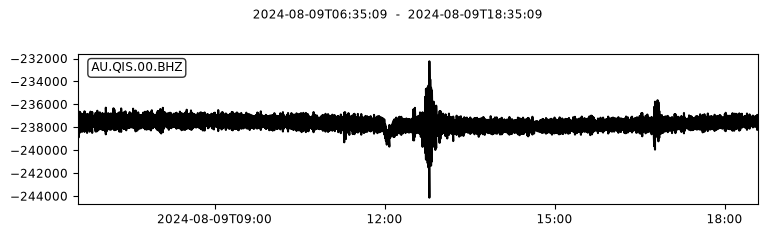

In [33]:
st.plot();

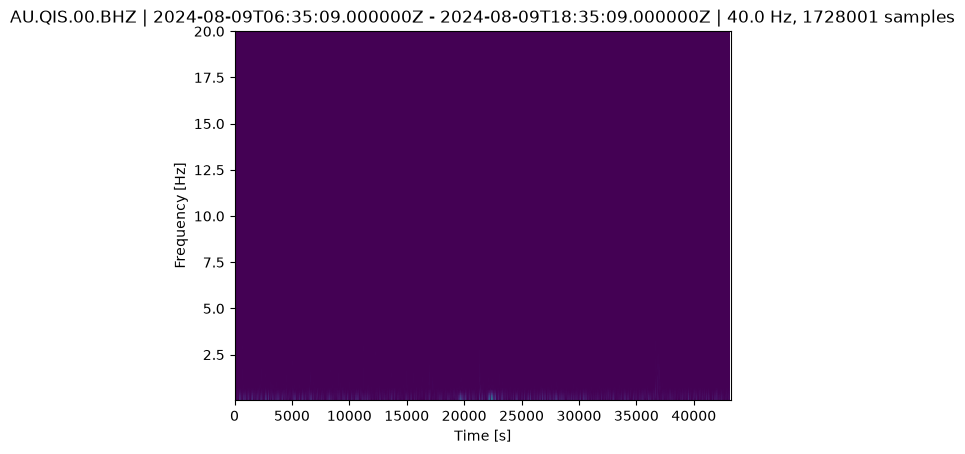

In [34]:
st.spectrogram();

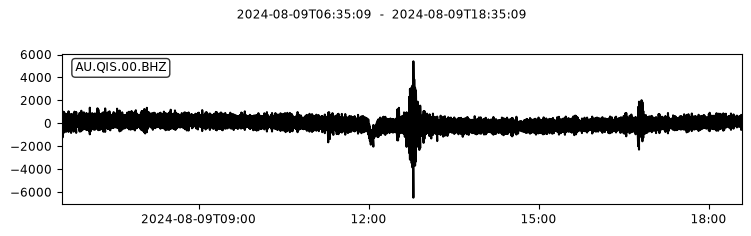

In [35]:
st_processed1 = st.copy()
st_processed1.detrend("demean")
st_processed1.plot();


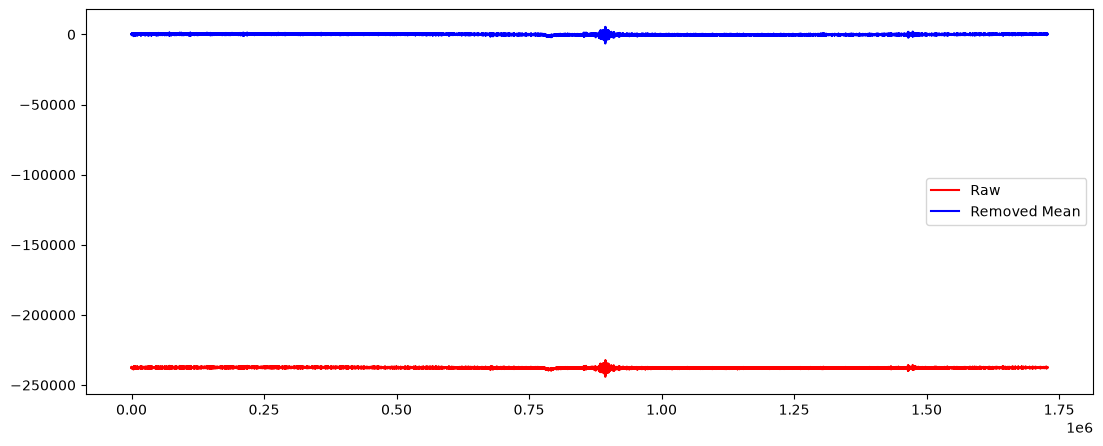

In [36]:
plt.figure(figsize=(13,5))
for tr in st:
    data1 = tr.data
plt.plot(data1, color="red", label = "Raw")

for tr in st_processed1:
    data2 = tr.data
plt.plot(data2, color="blue", label = "Removed Mean")

plt.legend()

In [37]:
test1_raw = st[0].data
test1_processed = st_processed1[0].data

print("Raw Mean: ", np.mean(test1_raw))
print("Processed Mean: ", np.mean(test1_processed))
print("Mean Difference: ", np.mean(test1_processed - test1_raw))

Raw Mean:  -237650.47633710862
Processed Mean:  1.4332011326483494e-11
Mean Difference:  237650.47633710867


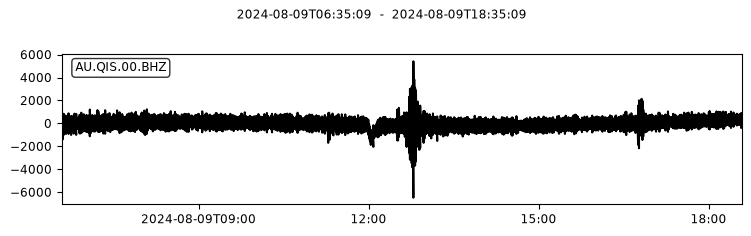

In [38]:
st_processed2 = st.copy()
st_processed2.detrend("linear")
st_processed2.plot();

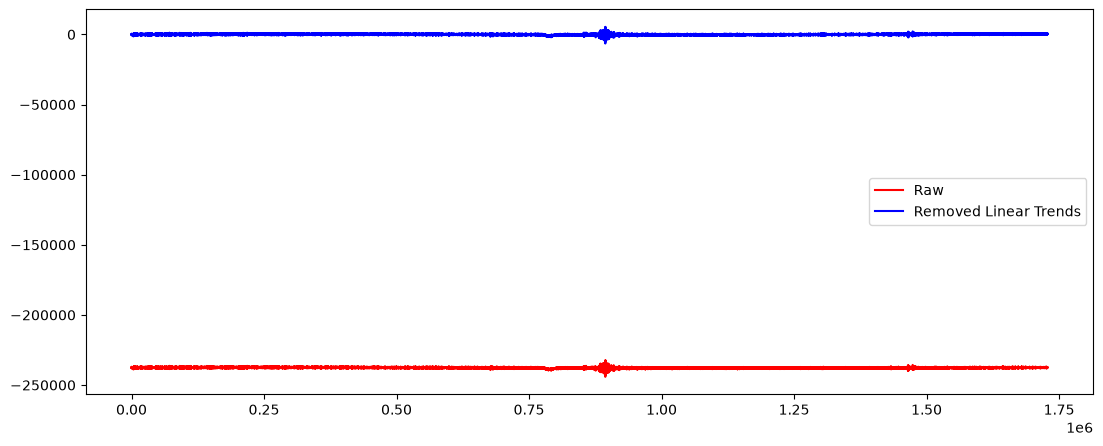

In [39]:
plt.figure(figsize=(13,5))
for tr in st:
    data1 = tr.data
plt.plot(data1, color="red", label = "Raw")

for tr in st_processed2:
    data2 = tr.data
plt.plot(data2, color="blue", label = "Removed Linear Trends")

plt.legend()

In [40]:
test2_raw = st[0].data
test2_processed = st_processed2[0].data

print("Raw Mean: ", np.mean(test2_raw))
print("Linear Removed (Mean): ", np.mean(test2_processed))
print("Mean Difference (Linear Removed): ", np.mean(test2_processed - test2_raw))

Raw Mean:  -237650.47633710862
Linear Removed (Mean):  -8.286286903585783e-10
Mean Difference (Linear Removed):  237650.47633710774


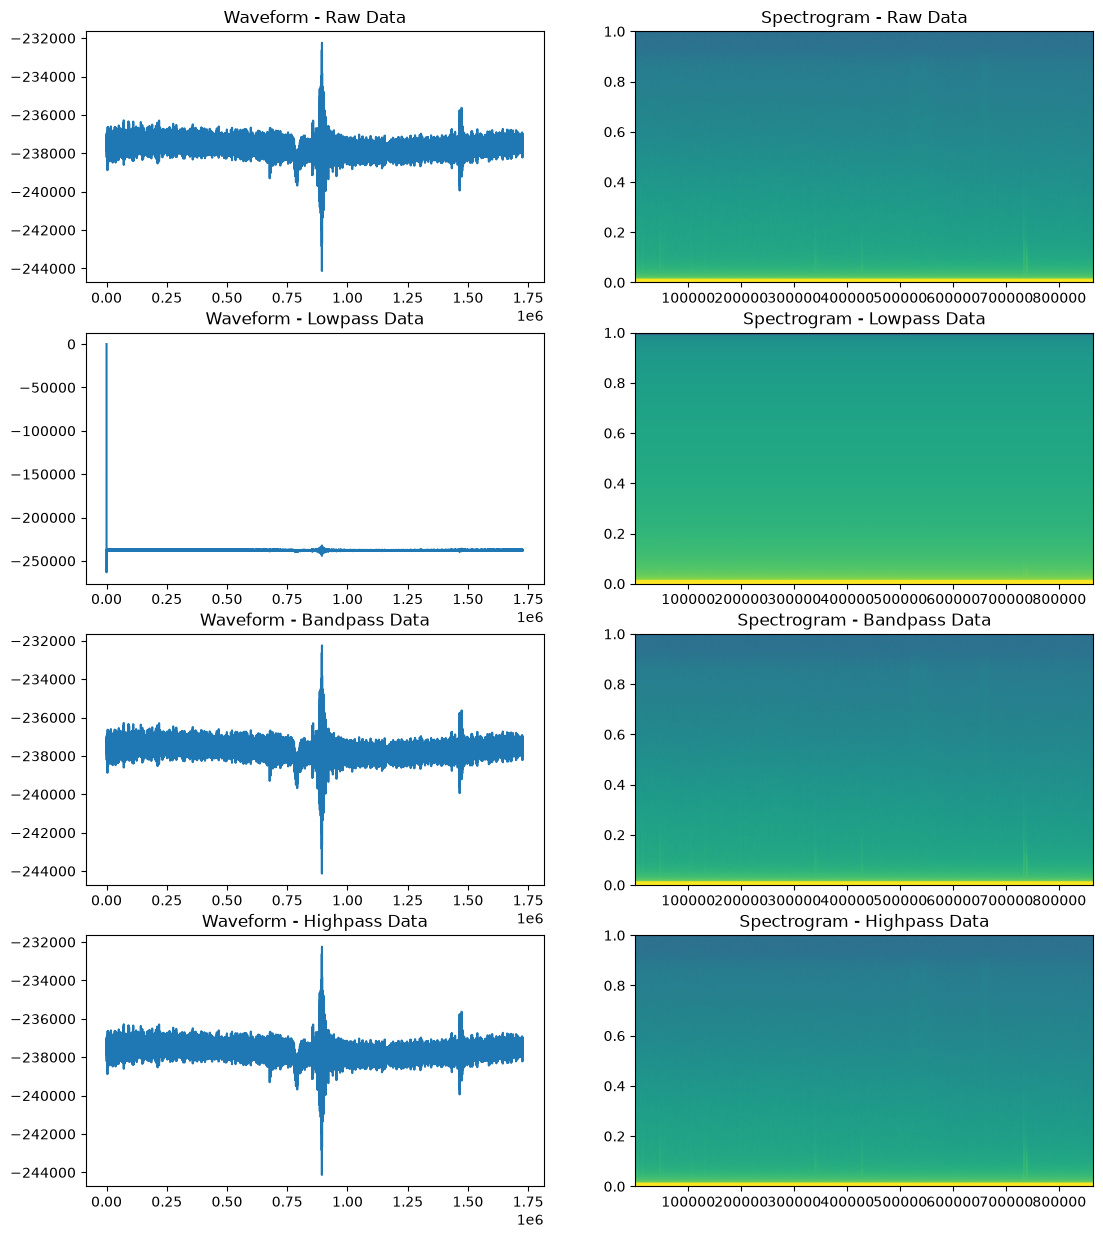

In [50]:
st_processed3 = st.copy()
st_processed3.filter("lowpass", freq=1)

st_processed4 = st.copy()
# st_processed4.filter("bandpass")

st_processed5 = st.copy()
# st_processed5.filter("highpass")

def extract_data(stream):
    for tr in stream:
        data = tr.data
    return data

st_data = extract_data(st)
st_lowpass_data = extract_data(st_processed3)
st_bandpass_data = extract_data(st_processed4)
st_highpass_data = extract_data(st_processed5)

fig, ax = plt.subplots(4,2, figsize=(13, 15))

ax[0,0].set_title("Waveform - Raw Data")
ax[0,0].plot(st_data)

ax[0,1].set_title("Spectrogram - Raw Data")
ax[0,1].specgram(st_data)

ax[1,0].set_title("Waveform - Lowpass Data")
ax[1,0].plot(st_lowpass_data)

ax[1,1].set_title("Spectrogram - Lowpass Data")
ax[1,1].specgram(st_lowpass_data)

ax[2,0].set_title("Waveform - Bandpass Data")
ax[2,0].plot(st_bandpass_data)

ax[2,1].set_title("Spectrogram - Bandpass Data")
ax[2,1].specgram(st_bandpass_data)

ax[3,0].set_title("Waveform - Highpass Data")
ax[3,0].plot(st_highpass_data)

ax[3,1].set_title("Spectrogram - Highpass Data")
ax[3,1].specgram(st_highpass_data)

plt.show()


### References

[1] https://www.australianexplorer.com/mt_isa.htm <br>
[2] Geoscience Australia. (2021). Australian National Seismograph Network Data Collection (Version Version 2.0, September 2018). Commonwealth of Australia (Geoscience Australia). https://doi.org/10.26186/144675